# 1주차 과제 - NSMC LSTM 감성 분석

- **데이터셋**: NSMC (네이버 영화 리뷰) — 학습 150,000건 / 테스트 50,000건
- **목표**: Bidirectional LSTM으로 감성 분류 구현, Test Accuracy **85% 이상** 달성

## 0. 환경 설정

In [37]:
!pip install -q KoNLPy

In [38]:
# Colab 한글 폰트 설치
!apt-get install -y fonts-nanum > /dev/null 2>&1

import numpy as np
import pandas as pd
import re
import time
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm

# 나눔폰트 경로 등록 및 적용
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from konlpy.tag import Okt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, Dense, LSTM, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 재현성을 위한 시드 고정
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## 1. 데이터 로드

In [39]:
# NSMC 데이터 다운로드
DATA_TRAIN_PATH = tf.keras.utils.get_file(
    "ratings_train.txt",
    "https://raw.github.com/ironmanciti/Infran_NLP/main/data/naver_movie/ratings_train.txt"
)
DATA_TEST_PATH = tf.keras.utils.get_file(
    "ratings_test.txt",
    "https://raw.github.com/ironmanciti/Infran_NLP/main/data/naver_movie/ratings_test.txt"
)

In [40]:
train_data = pd.read_csv(DATA_TRAIN_PATH, delimiter='\t')
test_data  = pd.read_csv(DATA_TEST_PATH,  delimiter='\t')

print("Train shape:", train_data.shape)
print("Test shape :", test_data.shape)
train_data.head()

Train shape: (150000, 3)
Test shape : (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


## 2. 데이터 전처리

과제 가이드라인의 4단계 전처리 파이프라인을 순서대로 구현

### STEP 1 — 결측치 제거

In [41]:
# NaN 제거
train_data.dropna(inplace=True)
test_data.dropna(inplace=True)

# 빈 문자열 제거
train_data = train_data[train_data['document'].str.strip() != '']
test_data  = test_data[test_data['document'].str.strip() != '']

print("결측치 제거 후")
print("Train:", train_data.shape, "| Test:", test_data.shape)
print("남은 null:")
print(train_data.isnull().sum())

결측치 제거 후
Train: (149995, 3) | Test: (49997, 3)
남은 null:
id          0
document    0
label       0
dtype: int64


### STEP 2 ~ 4 — 특수문자 제거 + 형태소 분석 + 길이 필터링

In [42]:
okt = Okt()

ALLOWED_POS = {'Noun', 'Verb', 'Adjective', 'Adverb'}  # Adverb 추가

def preprocessing(sentence):
    # STEP 2: 한글·공백만 남기기
    sentence = re.sub('[^가-힣 ]', '', str(sentence))

    # STEP 3: 형태소 분석 — stem=False (원형 복원 끄기)
    morphs = okt.pos(sentence, stem=False)
    tokens = [word for word, pos in morphs if pos in ALLOWED_POS]

    return tokens

In [43]:
%%time

train_sentences, train_labels = [], []
test_sentences,  test_labels  = [], []

# 훈련 데이터 전처리
for i, (sent, label) in enumerate(zip(train_data['document'], train_data['label'])):
    if i % 10000 == 0:
        print(f"Train processed = {i}")
    tokens = preprocessing(sent)
    # STEP 4: 형태소 1개 이하 제거
    if len(tokens) > 1:
        train_sentences.append(tokens)
        train_labels.append(label)

# 테스트 데이터 전처리
for i, (sent, label) in enumerate(zip(test_data['document'], test_data['label'])):
    if i % 10000 == 0:
        print(f"Test processed = {i}")
    tokens = preprocessing(sent)
    if len(tokens) > 1:
        test_sentences.append(tokens)
        test_labels.append(label)

print(f"\n전처리 완료 — Train: {len(train_sentences)}건, Test: {len(test_sentences)}건")

Train processed = 0
Train processed = 10000
Train processed = 20000
Train processed = 30000
Train processed = 40000
Train processed = 50000
Train processed = 60000
Train processed = 70000
Train processed = 80000
Train processed = 90000
Train processed = 100000
Train processed = 110000
Train processed = 120000
Train processed = 130000
Train processed = 140000
Test processed = 0
Test processed = 10000
Test processed = 20000
Test processed = 30000
Test processed = 40000

전처리 완료 — Train: 142717건, Test: 47694건
CPU times: user 13min 22s, sys: 1.86 s, total: 13min 24s
Wall time: 13min 21s


In [44]:
# 레이블을 numpy 배열로 변환
train_labels = np.array(train_labels)
test_labels  = np.array(test_labels)

print("Train labels shape:", train_labels.shape)
print("Test  labels shape:", test_labels.shape)
print("긍정(1) 비율 — train:", train_labels.mean().round(3),
      "| test:", test_labels.mean().round(3))

Train labels shape: (142717,)
Test  labels shape: (47694,)
긍정(1) 비율 — train: 0.496 | test: 0.501


## 3. Tokenizer + Padding

- `num_words=30000`
- `maxlen=100`

In [45]:
MAX_VOCAB = 30000
MAX_LEN   = 150

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_sentences)

train_sequences = tokenizer.texts_to_sequences(train_sentences)
test_sequences  = tokenizer.texts_to_sequences(test_sentences)

print("어휘 사전 크기:", len(tokenizer.word_index))

어휘 사전 크기: 98638


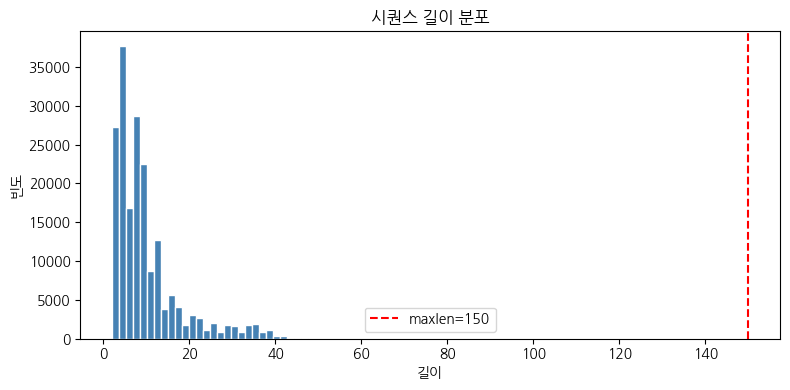

95th 퍼센타일 길이: 29


In [46]:
# 시퀀스 길이 분포 시각화
all_lens = [len(s) for s in train_sequences + test_sequences]
plt.figure(figsize=(8, 4))
plt.hist(all_lens, bins=40, color='steelblue', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'maxlen={MAX_LEN}')
plt.title('시퀀스 길이 분포')
plt.xlabel('길이')
plt.ylabel('빈도')
plt.legend()
plt.tight_layout()
plt.show()

print(f"95th 퍼센타일 길이: {int(np.percentile(all_lens, 95))}")

In [47]:
# Padding 적용
train_padded = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
test_padded  = pad_sequences(test_sequences,  maxlen=MAX_LEN, padding='post', truncating='post')

print("train_padded shape:", train_padded.shape)
print("test_padded shape :", test_padded.shape)

train_padded shape: (142717, 150)
test_padded shape : (47694, 150)


## 4. 모델 구현 — Bidirectional LSTM

In [48]:
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Embedding(MAX_VOCAB, 256, input_length=MAX_LEN),

    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.4),

    Bidirectional(LSTM(64)),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. 모델 학습

In [49]:
# 콜백 설정
callbacks = [
    # val_loss plateau 시 lr 절반으로 감소
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    # val_accuracy 기준 최고 성능 모델 저장
    ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1),
    # 7 epoch 동안 개선 없으면 조기 종료
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1)
]


In [50]:
%%time

history = model.fit(
    train_padded, train_labels,
    epochs=30,
    batch_size=64,
    validation_data=(test_padded, test_labels),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
2229/2230 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7796 - loss: 0.4439
Epoch 1: val_accuracy improved from None to 0.85189, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2230/2230 ━━━━━━━━━━━━━━━━━━━━ 101s 43ms/step - accuracy: 0.8242 - loss: 0.3843 - val_accuracy: 0.8519 - val_loss: 0.3387 - learning_rate: 0.0010
Epoch 2/30
2230/2230 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8823 - loss: 0.2782
Epoch 2: val_accuracy did not improve from 0.85189
2230/2230 ━━━━━━━━━━━━━━━━━━━━ 96s 43ms/step - accuracy: 0.8925 - loss: 0.2566 - val_accuracy: 0.8396 - val_loss: 0.3758 - learning_rate: 0.0010
Epoch 3/30
2229/2230 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9324 - loss: 0.1733
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.85189
2230/2230 ━━━━━━━━━━━━━━━━━━━━ 95s 43ms/step - accuracy: 0.9407 - loss: 0.1543 - val_accuracy: 0.8245 - val_loss: 0.4827 - le

## 6. 학습 곡선 시각화

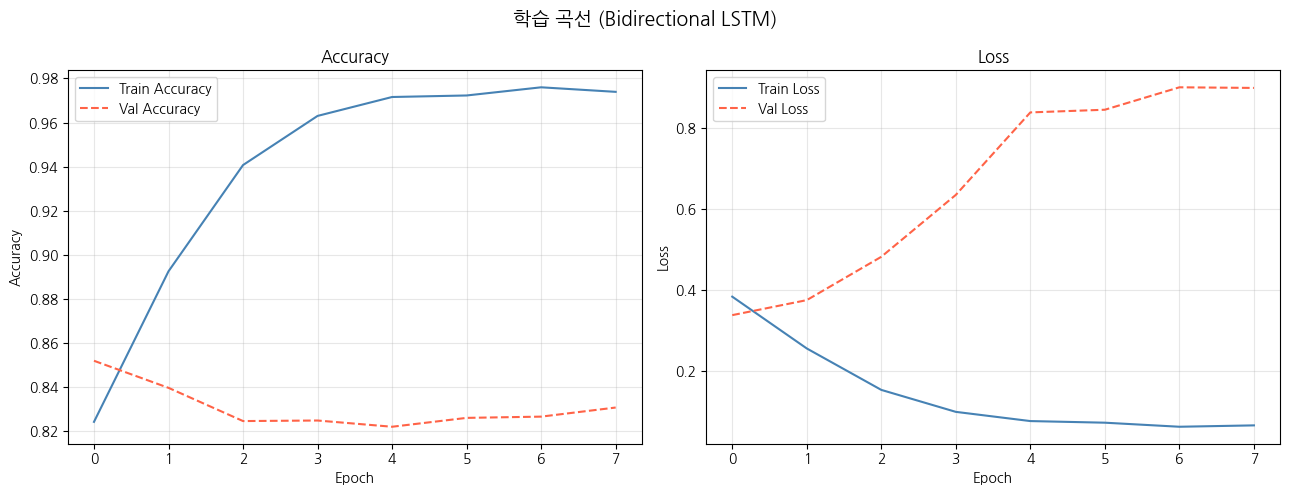

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy 곡선
ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato', linestyle='--')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

# Loss 곡선
ax2.plot(history.history['loss'],     label='Train Loss', color='steelblue')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('학습 곡선 (Bidirectional LSTM)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. 최종 성능 평가 (Test Accuracy)

In [52]:
loss, accuracy = model.evaluate(test_padded, test_labels, verbose=0)
print(f"Test Loss    : {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)")

if accuracy >= 0.85:
    print("Test Accuracy 85% 이상")
else:
    print("하이퍼파라미터 조정 필요")

Test Loss    : 0.3387
Test Accuracy: 0.8519  (85.19%)
Test Accuracy 85% 이상


## 8. Confusion Matrix

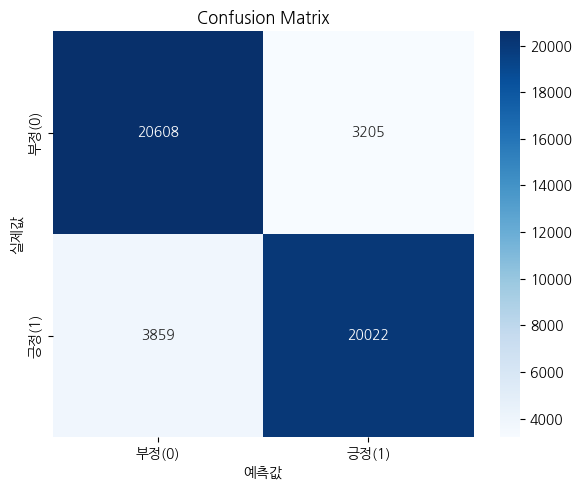


[Classification Report]
              precision    recall  f1-score   support

          부정       0.84      0.87      0.85     23813
          긍정       0.86      0.84      0.85     23881

    accuracy                           0.85     47694
   macro avg       0.85      0.85      0.85     47694
weighted avg       0.85      0.85      0.85     47694



In [53]:
# 예측값 생성
y_pred_prob = model.predict(test_padded, verbose=0)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()
y_true = test_labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['부정(0)', '긍정(1)'],
            yticklabels=['부정(0)', '긍정(1)'])
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# 상세 리포트
print("\n[Classification Report]")
print(classification_report(y_true, y_pred, target_names=['부정', '긍정']))

## 9. 샘플 예측 테스트

In [56]:
def predict_sentiment(texts):
    """리뷰 텍스트 리스트를 받아 긍정/부정 예측 결과 반환"""
    preprocessed = [preprocessing(t) for t in texts]
    seqs    = tokenizer.texts_to_sequences(preprocessed)
    padded  = pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')
    probs   = model.predict(padded, verbose=0).flatten()

    for text, prob in zip(texts, probs):
        label = '긍정' if prob >= 0.5 else '부정'
        print(f"[{label}] ({prob:.3f})  {text}")

sample_reviews = [
    "이 영화는 정말 감동적이고 배우들의 연기가 훌륭했다",
    "스토리가 너무 지루하고 억지스러워서 보다가 잠들었다",
    "오랜만에 본 수작이다 다시 보고 싶은 영화",
    "돈 아깝고 시간 낭비 최악이었음",
    "배우들 연기는 괜찮았지만 결말이 아쉬웠다"
]

predict_sentiment(sample_reviews)

[긍정] (0.973)  이 영화는 정말 감동적이고 배우들의 연기가 훌륭했다
[부정] (0.007)  스토리가 너무 지루하고 억지스러워서 보다가 잠들었다
[긍정] (0.985)  오랜만에 본 수작이다 다시 보고 싶은 영화
[부정] (0.005)  돈 아깝고 시간 낭비 최악이었음
[긍정] (0.557)  배우들 연기는 괜찮았지만 결말이 아쉬웠다
